Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Compiling model...
'compile' took 0.972284 s

Training model...

Step      Train loss                        Test loss                         Test metric   
0         [3.99e+00, 2.37e-02, 4.25e-04]    [4.00e+00, 2.37e-02, 4.25e-04]    [9.68e-01]    


/home/hridoy/miniconda3/envs/torch-env/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [2.25e-05, 2.61e-06, 3.90e-06]    [2.89e-05, 2.61e-06, 3.90e-06]    [5.11e-04]    
2000      [1.16e-05, 2.69e-08, 2.64e-07]    [1.41e-05, 2.69e-08, 2.64e-07]    [5.84e-04]    
3000      [5.82e-06, 8.69e-09, 1.15e-09]    [8.10e-06, 8.63e-09, 1.15e-09]    [4.07e-04]    
4000      [2.83e-06, 1.32e-12, 1.15e-08]    [4.52e-06, 1.18e-12, 1.15e-08]    [3.40e-04]    
5000      [2.11e-05, 6.48e-09, 2.96e-05]    [2.67e-05, 6.50e-09, 2.96e-05]    [6.12e-04]    
6000      [3.84e-06, 2.02e-07, 6.99e-06]    [6.46e-06, 2.02e-07, 6.99e-06]    [3.76e-04]    
7000      [6.23e-07, 7.99e-09, 2.57e-08]    [1.60e-06, 7.98e-09, 2.55e-08]    [2.40e-04]    
8000      [5.42e-07, 1.38e-10, 1.78e-10]    [1.61e-06, 1.38e-10, 1.91e-10]    [2.12e-04]    
9000      [5.34e-07, 2.30e-10, 2.60e-09]    [1.63e-06, 2.24e-10, 2.55e-09]    [2.00e-04]    
10000     [5.61e-07, 1.64e-07, 1.98e-07]    [1.71e-06, 1.64e-07, 1.97e-07]    [1.57e-04]    

Best model at step 9000:
  train loss: 5.37e-07
  test loss: 1.63e-06

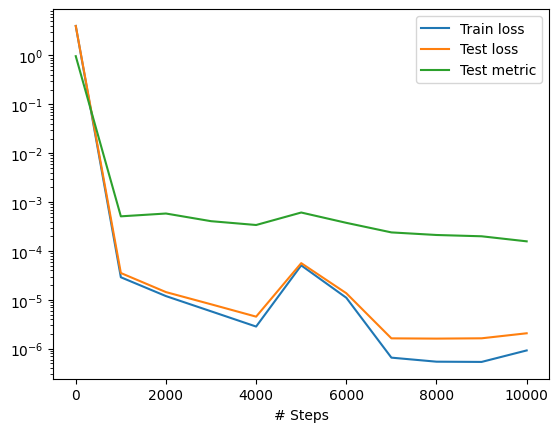

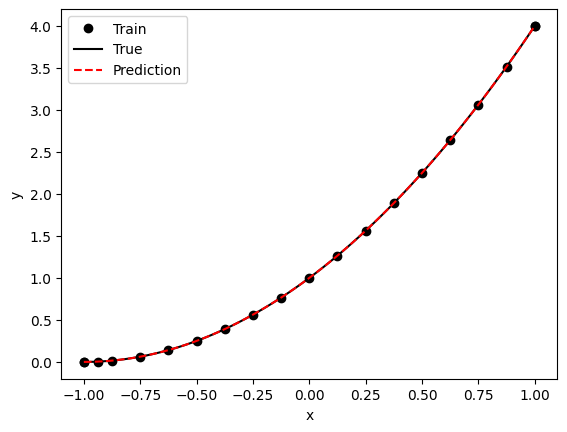

In [1]:
import deepxde as dde
import numpy as np

def pde(x, y):
    dy_xx = dde.grad.hessian(y, x)
    return dy_xx - 2

def boundary_l(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], -1)

def boundary_r(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 1)

def func(x):
    return (x + 1) ** 2

geom = dde.geometry.Interval(-1, 1)
bc_l = dde.icbc.DirichletBC(geom, func, boundary_l)
bc_r = dde.icbc.RobinBC(geom, lambda X, y: y, boundary_r)
data = dde.data.PDE(geom, pde, [bc_l, bc_r], 16, 2, solution=func, num_test=100)


layer_size = [1] + [50] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=10000)

dde.saveplot(losshistory, train_state, issave=False, isplot=True)
 